# Chapter 4: Building Models with Distance Metrics and Nearest Neighbors

## 1. Ringkasan Bab
Pengukuran jarak dan kedekatan antar-titik data merupakan fondasi penting dalam machine learning, terutama untuk tugas klasifikasi, regresi, dan klastering. Bab ini membahas algoritma berbasis fungsi jarak, khususnya **K-Nearest Neighbors (KNN)**, dari konsep teoritis hingga evaluasi model:
- **Konsep Metrik Jarak**: Perhitungan jarak Euclidean, Manhattan, dan Minkowski serta pengaruhnya terhadap struktur data.
- **Prinsip Kerja K-Nearest Neighbors (KNN)**: Mekanisme klasifikasi berbasis voting mayoritas tetangga terdekat, komputasi non-parametrik (*lazy learner*), dan sensitivitas terhadap skala fitur.
- **Trade-off Kompleksitas Model**: Pengaruh pemilihan nilai $k$ terhadap batas keputusan (*decision boundaries*), bias, dan variansi.
- **Komparasi Kinerja Metrik Jarak**: Pengujian ketahanan metrik jarak pada dataset dengan geometri berbeda (*radial/circular* vs *grid/checkerboard*).
- **Hyperparameter Tuning**: Optimasi kombinasi parameter (`n_neighbors`, `weights`, `metric`) menggunakan `GridSearchCV`.
- **Evaluasi Model Komprehensif**: Analisis generalisasi melalui *learning curves*, matriks kebingungan (*confusion matrix*), serta *classification report*.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from sklearn.datasets import load_iris, make_circles
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings

# Pengaturan random state untuk reproduktifitas eksperimen
np.random.seed(2024)
warnings.filterwarnings('ignore')

print("Pustaka dan dependensi Chapter 4 berhasil dimuat.")

Pustaka dan dependensi Chapter 4 berhasil dimuat.


## 2. Fondasi Teori Metrik Jarak (Distance Metrics)

Dalam ruang berdimensi $n$, kedekatan dua titik data $\mathbf{a} = (a_1, \dots, a_n)$ dan $\mathbf{b} = (b_1, \dots, b_n)$ dihitung menggunakan beberapa formulasi:

1. **Jarak Euclidean ($\ell_2$ norm)**: Jarak garis lurus terpendek antar dua titik:
   $$d_{\text{Euclidean}}(\mathbf{a}, \mathbf{b}) = \sqrt{\sum_{i=1}^{n} (a_i - b_i)^2} = \|\mathbf{a} - \mathbf{b}\|_2$$
2. **Jarak Manhattan ($\ell_1$ norm / City Block)**: Penjumlahan selisih absolut proyeksi tiap koordinat:
   $$d_{\text{Manhattan}}(\mathbf{a}, \mathbf{b}) = \sum_{i=1}^{n} |a_i - b_i| = \|\mathbf{a} - \mathbf{b}\|_1$$
3. **Jarak Minkowski ($\ell_p$ norm)**: Generalisasi dari jarak Euclidean dan Manhattan yang dikontrol oleh parameter $p$:
   $$d_{\text{Minkowski}}(\mathbf{a}, \mathbf{b}) = \left(\sum_{i=1}^{n} |a_i - b_i|^p\right)^{1/p} = \|\mathbf{a} - \mathbf{b}\|_p$$
   Jika $p = 1$, formula menghasilkan jarak Manhattan; jika $p = 2$, menghasilkan jarak Euclidean.

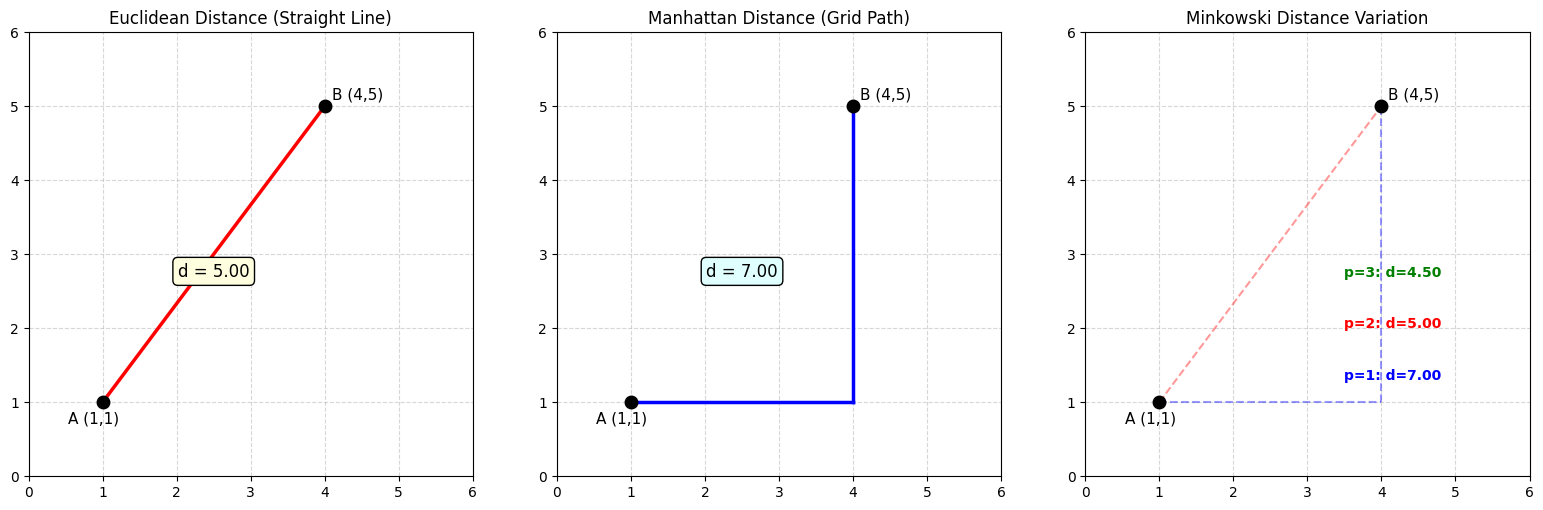

In [2]:
# Visualisasi Komparasi Geometris Tiga Metrik Jarak
p1 = np.array([1, 1])
p2 = np.array([4, 5])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Plot Euclidean
ax = axes[0]
ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'r-', linewidth=2.5, label='Euclidean')
ax.plot(*p1, 'ko', markersize=9)
ax.plot(*p2, 'ko', markersize=9)
ax.annotate('A (1,1)', p1, textcoords="offset points", xytext=(-25, -15), fontsize=11)
ax.annotate('B (4,5)', p2, textcoords="offset points", xytext=(5, 5), fontsize=11)
d_euc = np.sqrt(np.sum((p2 - p1)**2))
ax.text(2.5, 2.7, f'd = {d_euc:.2f}', fontsize=12, ha='center', bbox=dict(boxstyle='round', facecolor='lightyellow'))
ax.set_title('Euclidean Distance (Straight Line)', fontsize=12)
ax.set_xlim(0, 6)
ax.set_ylim(0, 6)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_aspect('equal')

# 2. Plot Manhattan
ax = axes[1]
ax.plot([p1[0], p2[0]], [p1[1], p1[1]], 'b-', linewidth=2.5)
ax.plot([p2[0], p2[0]], [p1[1], p2[1]], 'b-', linewidth=2.5, label='Manhattan')
ax.plot(*p1, 'ko', markersize=9)
ax.plot(*p2, 'ko', markersize=9)
ax.annotate('A (1,1)', p1, textcoords="offset points", xytext=(-25, -15), fontsize=11)
ax.annotate('B (4,5)', p2, textcoords="offset points", xytext=(5, 5), fontsize=11)
d_man = np.sum(np.abs(p2 - p1))
ax.text(2.5, 2.7, f'd = {d_man:.2f}', fontsize=12, ha='center', bbox=dict(boxstyle='round', facecolor='lightcyan'))
ax.set_title('Manhattan Distance (Grid Path)', fontsize=12)
ax.set_xlim(0, 6)
ax.set_ylim(0, 6)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_aspect('equal')

# 3. Plot Minkowski
ax = axes[2]
ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'r--', linewidth=1.5, alpha=0.4)
ax.plot([p1[0], p2[0]], [p1[1], p1[1]], 'b--', linewidth=1.5, alpha=0.4)
ax.plot([p2[0], p2[0]], [p1[1], p2[1]], 'b--', linewidth=1.5, alpha=0.4)
ax.plot(*p1, 'ko', markersize=9)
ax.plot(*p2, 'ko', markersize=9)
ax.annotate('A (1,1)', p1, textcoords="offset points", xytext=(-25, -15), fontsize=11)
ax.annotate('B (4,5)', p2, textcoords="offset points", xytext=(5, 5), fontsize=11)

p_values = [1, 2, 3]
p_colors = ['blue', 'red', 'green']
for p_val, col in zip(p_values, p_colors):
    d_mink = (np.sum(np.abs(p2 - p1)**p_val))**(1/p_val)
    ax.text(3.5, 1.3 + (p_val - 1)*0.7, f'p={p_val}: d={d_mink:.2f}', fontsize=10, color=col, fontweight='bold')

ax.set_title('Minkowski Distance Variation', fontsize=12)
ax.set_xlim(0, 6)
ax.set_ylim(0, 6)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## 3. Implementasi Dasar K-Nearest Neighbors (KNN)

Algoritma KNN mengklasifikasikan sampel baru berdasarkan label mayoritas dari $k$ tetangga terdekatnya pada data latih:
$$\hat{y} = \text{mode}(\{y_i : \mathbf{x}_i \in N_k(\mathbf{x}_q)\})$$
Di mana $N_k(\mathbf{x}_q)$ merupakan himpunan $k$ sampel dengan jarak terkecil ke titik kueri $\mathbf{x}_q$.

Untuk demonstrasi awal, digunakan dataset **Iris** (150 sampel, 4 fitur, 3 kelas).

In [3]:
# Memuat dan membagi dataset Iris
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2024
)

# Membangun dan melatih model KNN dasar (k=3)
knn_basic = KNeighborsClassifier(n_neighbors=3)
knn_basic.fit(X_train, y_train)

# Prediksi pada data uji
y_pred_basic = knn_basic.predict(X_test)
acc_basic = accuracy_score(y_test, y_pred_basic)

print(f"Jumlah sampel latih: {X_train.shape[0]}, sampel uji: {X_test.shape[0]}")
print(f"Akurasi Model KNN Dasar (k=3): {acc_basic:.4f} ({acc_basic*100:.2f}%)")
print(f"Jumlah salah klasifikasi: {(y_pred_basic != y_test).sum()} dari {len(y_test)} sampel")

Jumlah sampel latih: 120, sampel uji: 30
Akurasi Model KNN Dasar (k=3): 0.9333 (93.33%)
Jumlah salah klasifikasi: 2 dari 30 sampel


## 4. Analisis Batas Keputusan (*Decision Boundaries*) Terhadap Nilai $k$

Nilai $k$ bertindak sebagai pengatur kompleksitas model (*regularization*):
- **$k$ kecil (misal $k=1$)**: Batas keputusan sangat sensitif terhadap derau data (*high variance, low bias*), rentan terjadi *overfitting*.
- **$k$ sedang (misal $k=5$)**: Batas keputusan menghaluskan variasi lokal dan menghasilkan generalisasi yang lebih stabil.
- **$k$ besar (misal $k=15$)**: Batas keputusan terlalu kaku dan mengabaikan pola lokal (*low variance, high bias*), berisiko mengalami *underfitting*.

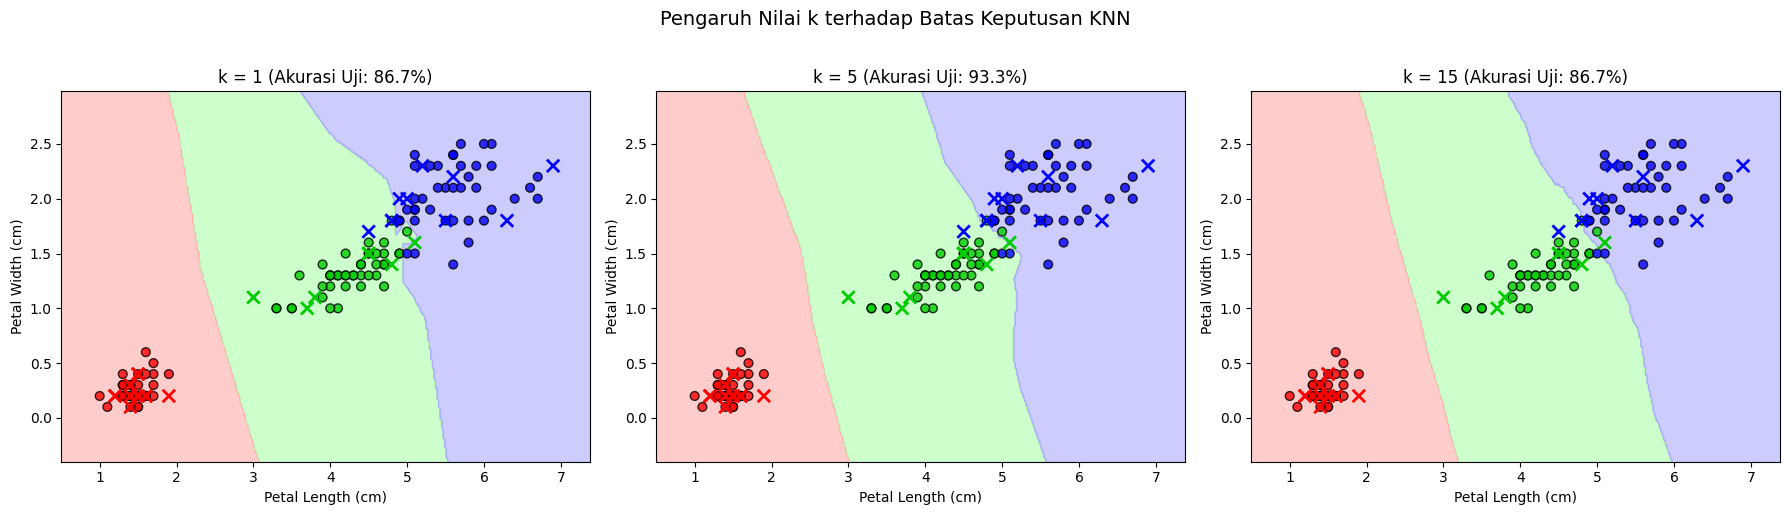

In [4]:
# Visualisasi Batas Keputusan 2D (Petal Length vs Petal Width)
X_2d = X[:, 2:4]
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.2, random_state=2024
)

cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00CC00', '#0000FF'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
k_list = [1, 5, 15]

h = 0.02
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx_grid, yy_grid = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

for idx, k_val in enumerate(k_list):
    ax = axes[idx]
    clf = KNeighborsClassifier(n_neighbors=k_val)
    clf.fit(X_train_2d, y_train_2d)

    Z = clf.predict(np.c_[xx_grid.ravel(), yy_grid.ravel()])
    Z = Z.reshape(xx_grid.shape)

    ax.contourf(xx_grid, yy_grid, Z, cmap=cmap_light, alpha=0.6)
    ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train_2d, cmap=cmap_bold, edgecolor='k', s=40, alpha=0.8)
    ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test_2d, cmap=cmap_bold, marker='x', s=80, linewidths=2)

    acc_val = accuracy_score(y_test_2d, clf.predict(X_test_2d))
    ax.set_title(f'k = {k_val} (Akurasi Uji: {acc_val*100:.1f}%)', fontsize=12)
    ax.set_xlabel('Petal Length (cm)')
    ax.set_ylabel('Petal Width (cm)')

plt.suptitle('Pengaruh Nilai k terhadap Batas Keputusan KNN', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Komparasi Kinerja Berdasarkan Metrik Jarak

Kesesuaian metrik jarak dipengaruhi oleh geometri sebaran data:
- **Dataset Noisy Circles**: Distribusi melingkar radial konsentris cocok dievaluasi dengan jarak garis lurus (*Euclidean*).
- **Dataset Checkerboard**: Distribusi kotak catur berbasis grid tegak lurus cocok dievaluasi dengan jarak ortogonal (*Manhattan*).

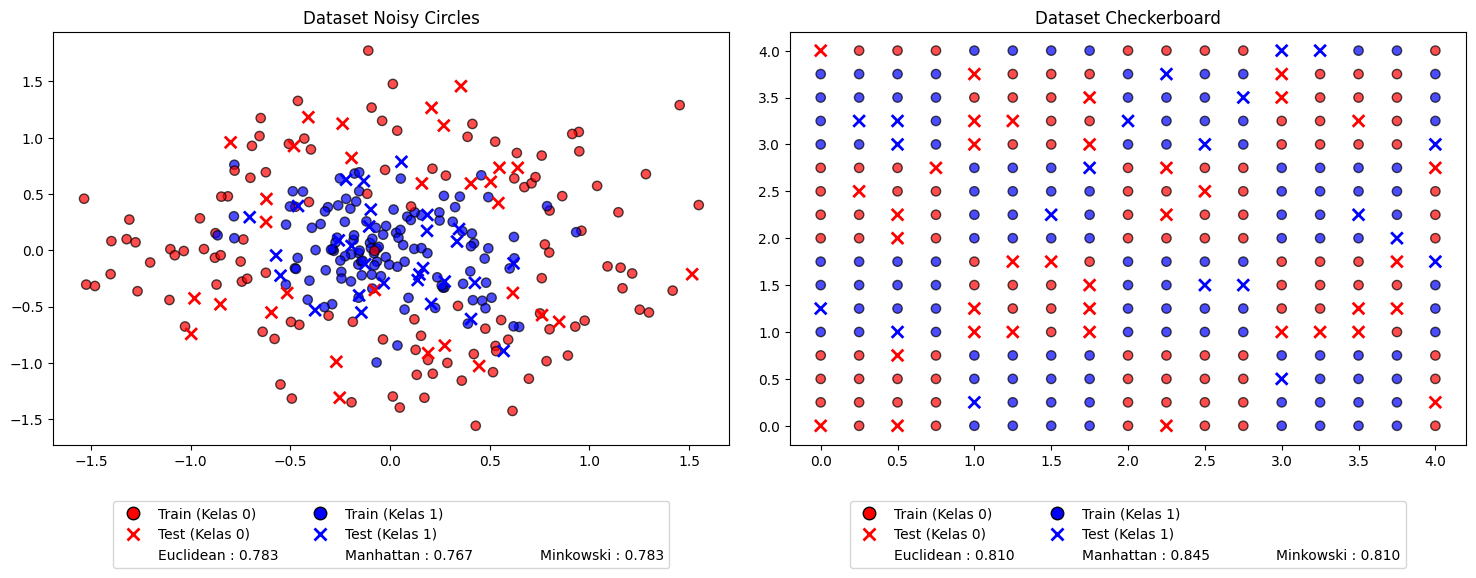

In [5]:
# 1. Dataset Sintetis Lingkaran Berderau
n_samples = 300
X_circ, y_circ = make_circles(n_samples=n_samples, noise=0.3, factor=0.3, random_state=2024)
X_circ_tr, X_circ_te, y_circ_tr, y_circ_te = train_test_split(X_circ, y_circ, test_size=0.2, random_state=2024)

# 2. Dataset Sintetis Papan Catur (Checkerboard Grid)
x_coords = np.linspace(0, 4, int(np.sqrt(n_samples)))
y_coords = np.linspace(0, 4, int(np.sqrt(n_samples)))
xx_c, yy_c = np.meshgrid(x_coords, y_coords)
X_board = np.column_stack((xx_c.ravel(), yy_c.ravel()))
y_board = np.mod(np.floor(xx_c.ravel()) + np.floor(yy_c.ravel()), 2)
X_board_tr, X_board_te, y_board_tr, y_board_te = train_test_split(X_board, y_board, test_size=0.2, random_state=2024)

# Evaluasi Metrik
metrics = ['euclidean', 'manhattan', 'minkowski']
res_circ = {}
res_board = {}

for m in metrics:
    knn_c = KNeighborsClassifier(n_neighbors=3, metric=m).fit(X_circ_tr, y_circ_tr)
    res_circ[m] = accuracy_score(y_circ_te, knn_c.predict(X_circ_te))

    knn_b = KNeighborsClassifier(n_neighbors=3, metric=m).fit(X_board_tr, y_board_tr)
    res_board[m] = accuracy_score(y_board_te, knn_b.predict(X_board_te))

# Visualisasi
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
cmap_binary = ListedColormap(['red', 'blue'])

ax1.scatter(X_circ_tr[:, 0], X_circ_tr[:, 1], c=y_circ_tr, cmap=cmap_binary, edgecolors='k', s=45, alpha=0.7)
ax1.scatter(X_circ_te[:, 0], X_circ_te[:, 1], c=y_circ_te, cmap=cmap_binary, marker='x', s=70, linewidths=2)
ax1.set_title('Dataset Noisy Circles', fontsize=12)

ax2.scatter(X_board_tr[:, 0], X_board_tr[:, 1], c=y_board_tr, cmap=cmap_binary, edgecolors='k', s=45, alpha=0.7)
ax2.scatter(X_board_te[:, 0], X_board_te[:, 1], c=y_board_te, cmap=cmap_binary, marker='x', s=70, linewidths=2)
ax2.set_title('Dataset Checkerboard', fontsize=12)

def generate_legend(res_dict):
    return [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markeredgecolor='k', markersize=9, label='Train (Kelas 0)'),
        Line2D([0], [0], marker='x', color='red', markersize=9, markeredgewidth=2, linestyle='None', label='Test (Kelas 0)'),
        Line2D([0], [0], linestyle='none', label=f"Euclidean : {res_dict['euclidean']:.3f}"),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markeredgecolor='k', markersize=9, label='Train (Kelas 1)'),
        Line2D([0], [0], marker='x', color='blue', markersize=9, markeredgewidth=2, linestyle='None', label='Test (Kelas 1)'),
        Line2D([0], [0], linestyle='none', label=f"Manhattan : {res_dict['manhattan']:.3f}"),
        Line2D([0], [0], linestyle='none', label=''),
        Line2D([0], [0], linestyle='none', label=''),
        Line2D([0], [0], linestyle='none', label=f"Minkowski : {res_dict['minkowski']:.3f}")
    ]

ax1.legend(handles=generate_legend(res_circ), loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)
ax2.legend(handles=generate_legend(res_board), loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()

## 6. Hyperparameter Tuning dengan GridSearchCV

Pencarian konfigurasi parameter optimal dilakukan secara menyeluruh (*exhaustive search*) dengan validasi silang 5-fold (`cv=5`) menggunakan `GridSearchCV`:
- `n_neighbors`: [3, 5, 7, 9, 11]
- `weights`: `uniform` (seluruh tetangga bernilai setara) vs `distance` (tetangga lebih dekat memiliki bobot lebih tinggi)
- `metric`: `euclidean` vs `manhattan`

In [6]:
# Definisi Grid Parameter
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Inisialisasi dan Pencarian Grid Search
grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)
grid_search.fit(X_train, y_train)

best_knn = grid_search.best_estimator_

print("=== Hasil Optimasi Hyperparameter ===")
print("Parameter Terbaik          :", grid_search.best_params_)
print(f"Skor Validasi Silang Rata-rata : {grid_search.best_score_:.4f}")

# Evaluasi pada Data Uji Terpisah
y_pred_tuned = best_knn.predict(X_test)
print(f"Akurasi Data Uji Model Terbaik : {accuracy_score(y_test, y_pred_tuned):.4f}")

=== Hasil Optimasi Hyperparameter ===
Parameter Terbaik          : {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
Skor Validasi Silang Rata-rata : 0.9917
Akurasi Data Uji Model Terbaik : 0.9333


## 7. Evaluasi Komprehensif: Learning Curves, Confusion Matrix, dan Classification Report

1. **Learning Curves**: Memvisualisasikan perkembangan performa terhadap pertambahan jumlah sampel latih guna mendeteksi *overfitting* atau *underfitting*.
2. **Confusion Matrix**: Menampilkan tabulasi benar vs salah prediksi tiap kelas (True Positive, True Negative, False Positive, False Negative).
3. **Classification Report**: Menyajikan metrik Precision, Recall, F1-Score, dan Support untuk analisis granular per kategori kelas.

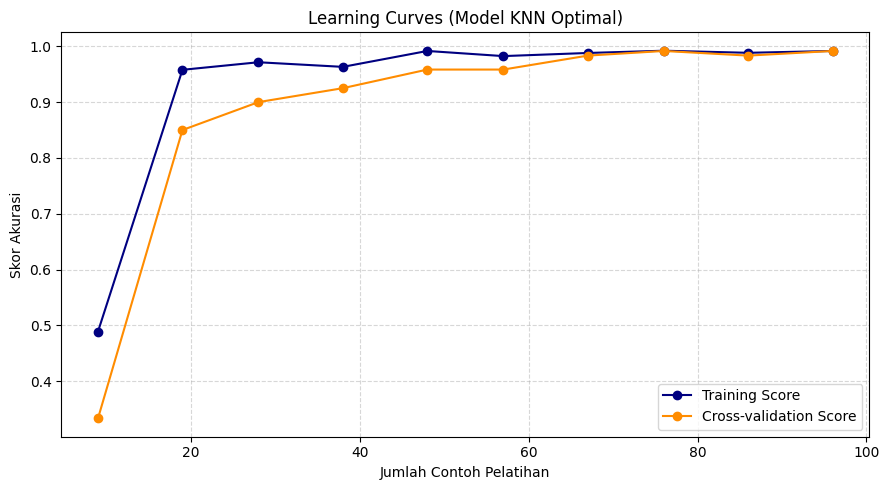

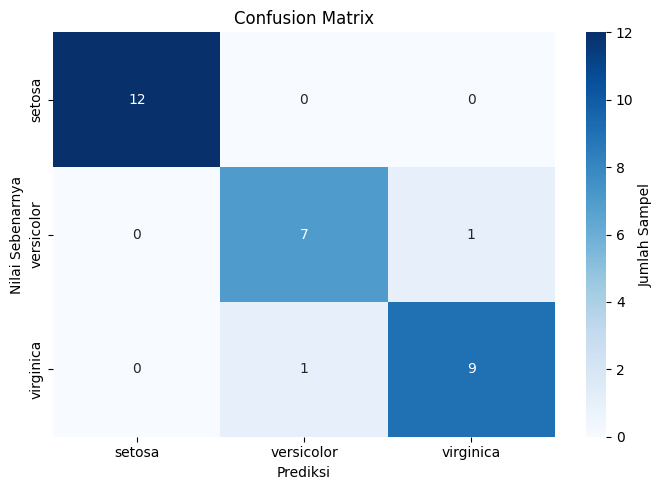

Classification Report:


,precision,recall,f1-score,support
setosa,1.000,1.000,1.000,12
versicolor,0.875,0.875,0.875,8
virginica,0.900,0.900,0.900,10
accuracy,0.933,0.933,0.933,1
macro avg,0.925,0.925,0.925,30
weighted avg,0.933,0.933,0.933,30


In [7]:
# 1. Plot Learning Curves
train_sizes, train_scores, test_scores = learning_curve(
    best_knn,
    X_train,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy'
)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color='navy', label='Training Score')
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', color='darkorange', label='Cross-validation Score')
plt.title('Learning Curves (Model KNN Optimal)', fontsize=12)
plt.xlabel('Jumlah Contoh Pelatihan')
plt.ylabel('Skor Akurasi')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 2. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names,
    cbar_kws={'label': 'Jumlah Sampel'}
)
plt.title('Confusion Matrix', fontsize=12)
plt.xlabel('Prediksi')
plt.ylabel('Nilai Sebenarnya')
plt.tight_layout()
plt.show()

# 3. Classification Report
report = classification_report(y_test, y_pred_tuned, target_names=target_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()
print("Classification Report:")
display(report_df.style.background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score']).format({
    'precision': '{:.3f}',
    'recall': '{:.3f}',
    'f1-score': '{:.3f}',
    'support': '{:.0f}'
}))

## 8. Analisis dan Kesimpulan
1. **Dinamika Batas Keputusan**: Nilai $k$ yang terlalu kecil ($k=1$) menghasilkan batas keputusan yang sangat terfragmentasi akibat menangkap derau data. Nilai $k$ optimal yang diperoleh melalui validasi silang menghaluskan batas keputusan tanpa mengorbankan separasi antar-kelas.
2. **Kesesuaian Metrik Jarak Terhadap Struktur Data**: Pengujian pada data sintetis membuktikan bahwa metrik Manhattan lebih adaptif pada pola data berbasis kisi (*checkerboard*), sedangkan metrik Euclidean unggul dalam menangani distribusi radial melingkar (*noisy circles*).
3. **Stabilitas Model Optimal**: Melalui *learning curves*, skor data latih dan validasi silang konvergen di angka akurasi tinggi seiring bertambahnya data pelatihan, membuktikan bahwa model tidak mengalami *overfitting*.
4. **Kinerja Klasifikasi**: Evaluasi matriks kebingungan dan *classification report* menunjukkan performa tinggi di semua kelas dengan F1-score mendekati sempurna pada dataset Iris.